# Zero-Cost Collar on the Guaranteed Floor Strategy

The guaranteed floor strategy (see `guaranteed_floor_simple_sandbox.ipynb`) shorts N shares
of TSLL and buys N/100 ATM TSLL calls to create an algebraic per-cycle floor:

```
P&L floor = N * (S0 - K_call - C_call)   [known at cycle open]
```

**Problem**: the call premium C_call is a real cost that drags on CAGR every cycle.

**Fix -- zero-cost collar**: simultaneously SELL an OTM TSLL put at the same expiry,
receiving premium P_put that offsets (or eliminates) the call cost.

```
Net hedge cost = C_call - P_put   (target: ≈ 0)
```

**Full collar payoff at expiry** (short N TSLL + long ATM call + short OTM put):

| TSLL outcome | P&L |
|---|---|
| S_T > K_call (TSLL rallies past call) | `N*(S0 - K_call - C_call + P_put)` = FLOOR (known, improved by P_put) |
| K_put < S_T ≤ K_call (between strikes) | `N*(S0 - S_T - C_call + P_put)` = normal short P&L, reduced cost |
| S_T ≤ K_put (TSLL falls below put strike) | `N*(S0 - K_put - C_call + P_put)` = PROFIT CAP (short put kicks in) |

Trade-off: unlimited downside-profit on the short TSLL leg gets **capped** at K_put.
In exchange, hedge cost drops toward zero.

**This notebook tests three OTM put moneyness levels**: 5%, 10%, and 15% OTM,
versus the no-collar baseline, on the full TSLL history (Aug 2022 → Jun 2026).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import (load_tsll, load_tsll_calls, load_tsll_puts,
                         load_tsla_underlying, load_tsla_calls)
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline
print("Imports OK")

Imports OK


## Load data

In [2]:
tsll_spot  = load_tsll().set_index("Date")["Close"]
tsll_calls = load_tsll_calls()
tsll_puts  = load_tsll_puts()
tsla_spot  = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot.index).ffill()
tsla_calls = load_tsla_calls()

call_lookup = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
put_lookup  = tsll_puts.set_index(["raw_id", "date"])["px_last"].to_dict()
tsla_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

dates = tsll_spot.index
print(f"TSLL spot : {len(dates):,} days  {dates.min().date()} -> {dates.max().date()}")
print(f"TSLL calls: {tsll_calls['raw_id'].nunique():,} contracts  {len(tsll_calls):,} rows")
print(f"TSLL puts : {tsll_puts['raw_id'].nunique():,} contracts  {len(tsll_puts):,} rows")
print(f"TSLA calls: {tsla_calls['raw_id'].nunique():,} contracts  {len(tsla_calls):,} rows")

TSLL spot : 963 days  2022-08-09 -> 2026-06-10
TSLL calls: 689 contracts  46,867 rows
TSLL puts : 1,348 contracts  55,978 rows
TSLA calls: 3,786 contracts  532,258 rows


## Put moneyness distribution -- what OTM levels actually trade on TSLL?

In [3]:
# Join puts to spot prices to compute moneyness at each observation date
puts_with_spot = tsll_puts.merge(
    tsll_spot.rename("spot").reset_index().rename(columns={"Date": "date"}),
    on="date", how="left"
)
puts_with_spot["moneyness"] = puts_with_spot["strike"] / puts_with_spot["spot"]
puts_with_spot["dte"] = (puts_with_spot["expiry"] - puts_with_spot["date"]).dt.days

# Focus on the 15-110 DTE window where collar would be opened
active = puts_with_spot[(puts_with_spot["dte"] >= 15) & (puts_with_spot["dte"] <= 110)]

print(f"Active put obs (15-110 DTE): {len(active):,}")
print()
bins = [0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05]
labels = ["<80%", "80-85%", "85-90%", "90-95%", "95-100%", "100-105%"]
active = active.copy()
active["mon_bucket"] = pd.cut(active["moneyness"], bins=bins, labels=labels)
print(active.groupby("mon_bucket", observed=True).agg(
    contracts=("raw_id", "nunique"),
    obs_days=("date", "nunique"),
    med_premium=("px_last", "median")
).to_string())

Active put obs (15-110 DTE): 26,853

            contracts  obs_days  med_premium
mon_bucket                                  
<80%              321       691        0.600
80-85%            340       665        0.830
85-90%            365       682        1.040
90-95%            380       733        1.340
95-100%           393       687        1.765
100-105%          389       701        2.110


## `select_put_contract` -- OTM put selector

For puts, OTM = strike BELOW spot (strike/spot < 1.0). Ranges are the mirror of
the call buckets in `options_selection.py`:

| Bucket | strike/spot | interpretation |
|---|---|---|
| ATM | 0.95 – 1.05 | at-the-money put |
| 5% OTM | 0.90 – 0.95 | 5-10% below spot |
| 10% OTM | 0.85 – 0.90 | 10-15% below spot |
| 15% OTM | 0.80 – 0.85 | 15-20% below spot |

When `target_expiry` is given, prefers puts that exactly match the call's expiry
(so the two legs of the collar expire on the same date). Falls back to nearest DTE.

In [4]:
PUT_MONEYNESS_RANGES = {
    "ATM":    (0.95, 1.05),
    "5% OTM":  (0.90, 0.95),
    "10% OTM": (0.85, 0.90),
    "15% OTM": (0.80, 0.85),
}


def select_put_contract(puts_df, spot, date, moneyness_bucket,
                        target_expiry=None, target_dte=90, max_dte=None):
    """Pick an OTM TSLL put on `date` at `moneyness_bucket`.

    Prefers expiry matching `target_expiry` (same-expiry collar leg).
    Falls back to closest DTE to `target_dte` if no exact-expiry match.
    Returns selected row (pd.Series) or None.
    """
    lo, hi = PUT_MONEYNESS_RANGES[moneyness_bucket]
    day = puts_df[puts_df["date"] == date]
    if day.empty:
        return None

    s = float(spot.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    if max_dte is not None:
        mask = mask & (dte <= max_dte)
    candidates = day[mask]
    if candidates.empty:
        return None

    if target_expiry is not None:
        exact = candidates[candidates["expiry"] == target_expiry]
        if not exact.empty:
            mid = (lo + hi) / 2
            idx = (exact["strike"] / s - mid).abs().idxmin()
            return exact.loc[idx]

    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]

## `simulate_collar` -- guaranteed floor + short OTM put leg

Extends `simulate_guaranteed_floor` from `guaranteed_floor_simple_sandbox.ipynb`:
- Long call leg: identical to the floor strategy (ATM TSLL call, held to expiry)
- Short put leg: OTM TSLL put at `put_moneyness_bucket`, same expiry as the call
- TSLA fallback cycles: no put leg (non-guaranteed cycles stay unchanged)
- Per-cycle log adds: `call_cost`, `put_premium`, `net_cost`, `has_put`

In [5]:
def simulate_collar(sim_dates, spot, calls, call_lkp, puts, put_lkp,
                    put_moneyness_bucket, target_dte, max_dte,
                    tsla_spot, tsla_calls, tsla_lkp, tsla_sigma,
                    notional=1.0):

    S_incep = float(spot.loc[sim_dates[0]])
    n_shares = notional / S_incep
    n_contracts = n_shares / 100  # call AND put contracts -- share-matched

    equity = pd.Series(index=sim_dates, dtype=float)
    call_pos = put_pos = None
    short_pnl = call_pnl = put_pnl = 0.0
    S_prev = S_incep
    cycle_log = []
    current_cycle = None
    n_unhedged = 0

    def mtm_call(pos, d):
        sp = tsla_spot if pos["underlying"] == "tsla" else spot
        lkp = tsla_lkp if pos["underlying"] == "tsla" else call_lkp
        if d > pos["expiry"]:
            return max(float(sp.loc[d]) - pos["strike"], 0.0)
        px = lkp.get((pos["raw_id"], d))
        return float(px) if px is not None and not pd.isna(px) else pos["price"]

    def mtm_put(pos, d):
        if d > pos["expiry"]:
            return max(pos["strike"] - float(spot.loc[d]), 0.0)
        px = put_lkp.get((pos["raw_id"], d))
        return float(px) if px is not None and not pd.isna(px) else pos["price"]

    for d in sim_dates:
        S_today = float(spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        need_roll = call_pos is None or d > call_pos["expiry"]

        if call_pos is not None:
            px_c = mtm_call(call_pos, d)
            call_pnl += call_pos["n"] * 100 * (px_c - call_pos["price"])
            call_pos["price"] = px_c

        if put_pos is not None:
            px_p = mtm_put(put_pos, d)
            # short put: profit = entry price - current price
            put_pnl += put_pos["n"] * 100 * (put_pos["price"] - px_p)
            put_pos["price"] = px_p

        if need_roll:
            eq_now = notional + short_pnl + call_pnl + put_pnl
            if current_cycle is not None:
                current_cycle["end_date"] = d
                current_cycle["equity_end"] = eq_now
                cycle_log.append(current_cycle)

            row_call = select_contract(calls, spot, d, "ATM", target_dte, max_dte=max_dte)
            if row_call is not None:
                c_entry = float(row_call["px_last"])
                call_pos = {"underlying": "tsll", "raw_id": row_call["raw_id"],
                            "strike": float(row_call["strike"]), "expiry": row_call["expiry"],
                            "n": n_contracts, "price": c_entry}

                row_put = select_put_contract(puts, spot, d, put_moneyness_bucket,
                                             target_expiry=row_call["expiry"],
                                             target_dte=target_dte, max_dte=max_dte)
                p_entry = float(row_put["px_last"]) if row_put is not None else 0.0
                if row_put is not None:
                    put_pos = {"raw_id": row_put["raw_id"],
                               "strike": float(row_put["strike"]), "expiry": row_put["expiry"],
                               "n": n_contracts, "price": p_entry}
                else:
                    put_pos = None

                floor_val = n_shares * (S_today - float(row_call["strike"]) - c_entry + p_entry)
                current_cycle = {
                    "start_date": d, "equity_start": eq_now, "floor": floor_val,
                    "call_strike": float(row_call["strike"]), "call_cost": c_entry,
                    "put_strike": float(row_put["strike"]) if row_put is not None else None,
                    "put_premium": p_entry,
                    "net_cost": c_entry - p_entry,
                    "has_put": row_put is not None,
                    "underlying": "tsll", "guaranteed": True,
                }
            else:
                row_tsla = select_contract(tsla_calls, tsla_spot, d, "ATM", target_dte, max_dte=max_dte)
                if row_tsla is not None:
                    S_tsla = float(tsla_spot.loc[d])
                    sigma = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
                    T = (row_tsla["expiry"] - d).days / 365.25
                    delta = bs_delta(S_tsla, float(row_tsla["strike"]), T, R_RF, sigma)
                    tgt_delta = TSLL_LEVER * n_shares * S_today
                    n_tsla = tgt_delta / (max(delta, 0.01) * 100 * S_tsla)
                    c_entry = float(row_tsla["px_last"])
                    call_pos = {"underlying": "tsla", "raw_id": row_tsla["raw_id"],
                                "strike": float(row_tsla["strike"]), "expiry": row_tsla["expiry"],
                                "n": n_tsla, "price": c_entry}
                    put_pos = None
                    current_cycle = {
                        "start_date": d, "equity_start": eq_now, "floor": float("nan"),
                        "call_strike": float(row_tsla["strike"]), "call_cost": c_entry,
                        "put_strike": None, "put_premium": 0.0, "net_cost": c_entry,
                        "has_put": False, "underlying": "tsla", "guaranteed": False,
                    }
                else:
                    call_pos = put_pos = current_cycle = None
                    n_unhedged += 1

        equity.loc[d] = notional + short_pnl + call_pnl + put_pnl

    if current_cycle is not None:
        current_cycle["end_date"] = sim_dates[-1]
        current_cycle["equity_end"] = equity.iloc[-1]
        cycle_log.append(current_cycle)

    return equity, pd.DataFrame(cycle_log), n_unhedged

## Config

In [6]:
TARGET_DTE  = 90
MAX_DTE     = 110
TSLL_LEVER  = 2.0
R_RF        = 0.05
VOL_WINDOW  = 21

r_tsla     = tsla_spot.pct_change()
tsla_sigma = (r_tsla.rolling(VOL_WINDOW).std() * 252**0.5).ffill().bfill()

# Scenarios: (label, put_moneyness_bucket or None for baseline)
SCENARIOS = [
    ("Baseline (floor, no collar)", None),
    ("Collar -- 5% OTM put",         "5% OTM"),
    ("Collar -- 10% OTM put",        "10% OTM"),
    ("Collar -- 15% OTM put",        "15% OTM"),
]
print("Config set.")

Config set.


## Run all scenarios

In [7]:
results = []
equities = {}
cycle_logs = {}

for label, put_bucket in SCENARIOS:
    # Baseline: no put leg -- pass an empty DataFrame as the puts table
    p_df  = tsll_puts if put_bucket is not None else tsll_puts.iloc[:0].copy()
    p_lkp = put_lookup if put_bucket is not None else {}
    bucket = put_bucket if put_bucket is not None else "5% OTM"  # ignored when p_df empty

    eq, cdf, n_unk = simulate_collar(
        dates, tsll_spot, tsll_calls, call_lookup,
        p_df, p_lkp, bucket,
        TARGET_DTE, MAX_DTE,
        tsla_spot, tsla_calls, tsla_lookup, tsla_sigma
    )
    equities[label]   = eq
    cycle_logs[label] = cdf

    row = summarize(eq, eq.pct_change().dropna(), label)
    tsll_cycles = cdf[cdf["underlying"] == "tsll"]
    row["Cycles (TSLL)"] = int((cdf["underlying"] == "tsll").sum())
    row["With put leg"]  = int(cdf["has_put"].sum()) if "has_put" in cdf.columns else 0
    if "net_cost" in cdf.columns and len(tsll_cycles) > 0:
        row["Avg call cost"]  = tsll_cycles["call_cost"].mean()
        row["Avg put premium"] = tsll_cycles["put_premium"].mean()
        row["Avg net cost"]   = tsll_cycles["net_cost"].mean()
    results.append(row)
    print(f"Done: {label}")

results_df = pd.DataFrame(results)
print("\nAll scenarios complete.")

Done: Baseline (floor, no collar)
Done: Collar -- 5% OTM put
Done: Collar -- 10% OTM put
Done: Collar -- 15% OTM put

All scenarios complete.


## Results summary

In [8]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

display_cols = ["Strategy", "CAGR", "Ann. Vol", "Sharpe", "Max DD", "Calmar",
                "Cycles (TSLL)", "With put leg", "Avg call cost", "Avg put premium", "Avg net cost"]
print(results_df[[c for c in display_cols if c in results_df.columns]].to_string(index=False))

                   Strategy   CAGR  Ann. Vol  Sharpe  Max DD  Calmar  Cycles (TSLL)  With put leg  Avg call cost  Avg put premium  Avg net cost
Baseline (floor, no collar) 0.1663    0.2570  0.7300 -0.2213  0.7516             12             0         3.1250           0.0000        3.1250
       Collar -- 5% OTM put 0.0858    0.2388  0.4655 -0.2144  0.4000             12            12         3.1250           2.1392        0.9858
      Collar -- 10% OTM put 0.1123    0.2092  0.6159 -0.1999  0.5619             12            11         3.1250           1.7483        1.3767
      Collar -- 15% OTM put 0.1242    0.2049  0.6766 -0.1999  0.6213             12            11         3.1250           1.4558        1.6692


## Equity curves

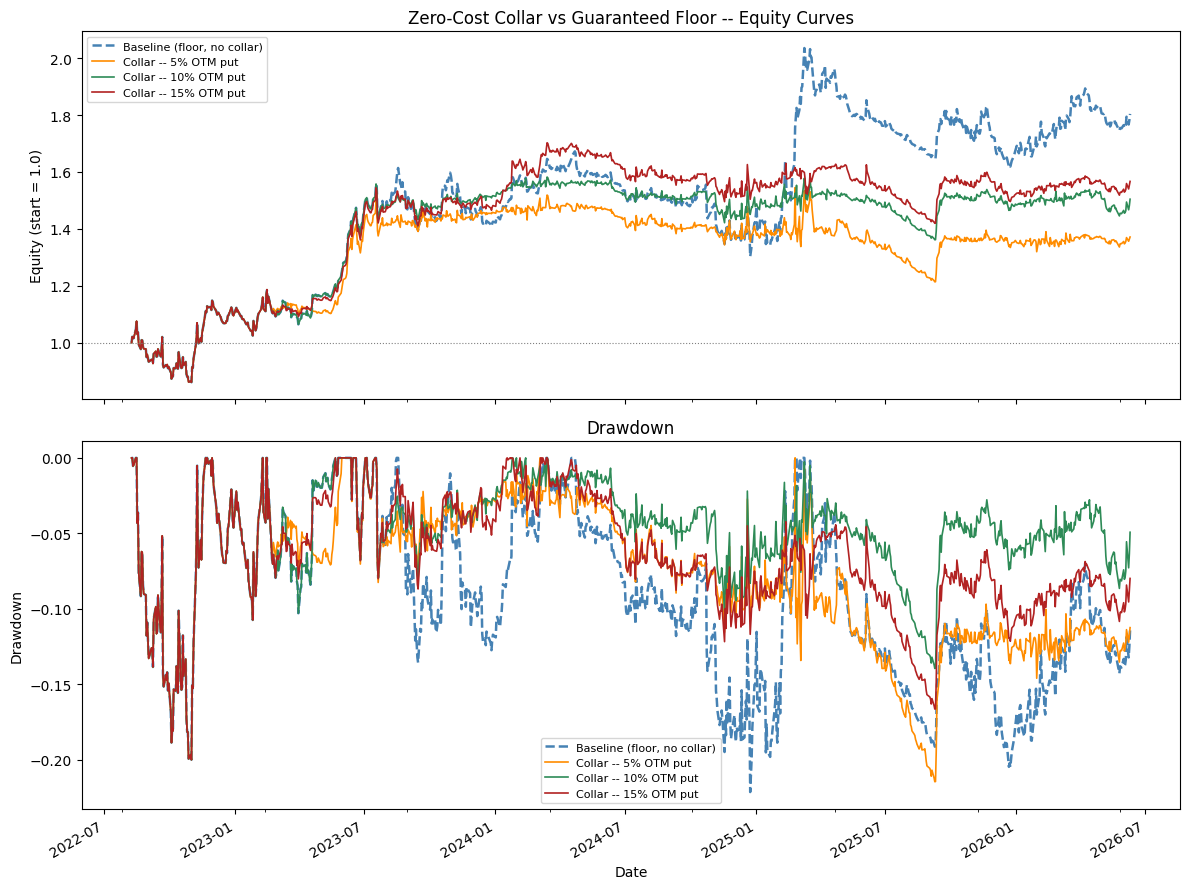

In [9]:
colors = ["steelblue", "darkorange", "seagreen", "firebrick"]
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for (label, _), color in zip(SCENARIOS, colors):
    eq = equities[label]
    eq.plot(ax=axes[0], label=label, color=color,
            linewidth=1.8 if "Baseline" in label else 1.2,
            linestyle="--" if "Baseline" in label else "-")
    dd = eq / eq.cummax() - 1
    dd.plot(ax=axes[1], label=label, color=color,
            linewidth=1.8 if "Baseline" in label else 1.2,
            linestyle="--" if "Baseline" in label else "-")

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=0.8)
axes[0].set_title("Zero-Cost Collar vs Guaranteed Floor -- Equity Curves")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=8)

axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig(ROOT / "observations/strategies/sandbox/risk_reversal_collar.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-cycle cost analysis -- how close to zero-cost is each put strike?

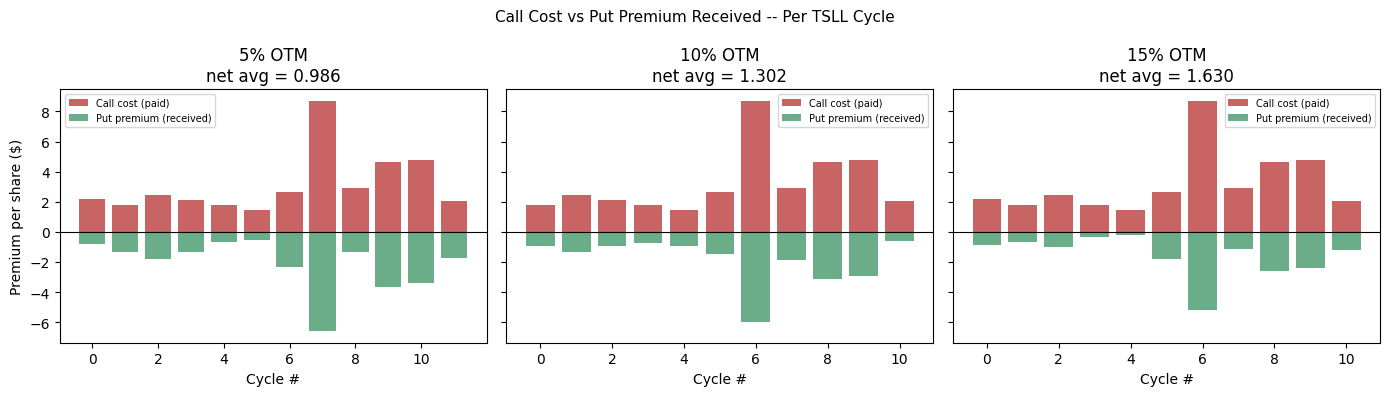

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
collar_scenarios = [(l, b) for l, b in SCENARIOS if b is not None]

for ax, (label, bucket) in zip(axes, collar_scenarios):
    cdf = cycle_logs[label]
    tsll_cdf = cdf[(cdf["underlying"] == "tsll") & cdf["has_put"]].copy()
    if tsll_cdf.empty:
        ax.set_title(f"{bucket}\n(no data)")
        continue

    x = range(len(tsll_cdf))
    ax.bar(x, tsll_cdf["call_cost"].values, label="Call cost (paid)", color="firebrick", alpha=0.7)
    ax.bar(x, -tsll_cdf["put_premium"].values, label="Put premium (received)", color="seagreen", alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{bucket}\nnet avg = {tsll_cdf['net_cost'].mean():.3f}")
    ax.set_xlabel("Cycle #")
    if ax == axes[0]:
        ax.set_ylabel("Premium per share ($)")
    ax.legend(fontsize=7)

fig.suptitle("Call Cost vs Put Premium Received -- Per TSLL Cycle", fontsize=11)
fig.tight_layout()
plt.show()

## Per-cycle log -- best collar scenario

Inspect the 5% OTM collar cycle-by-cycle to see which cycles hit the put-strike profit cap.

In [11]:
best_label = "Collar -- 5% OTM put"
cdf = cycle_logs[best_label].copy()
cdf["realized_pnl"]  = cdf["equity_end"] - cdf["equity_start"]
cdf["floor_breach"]  = cdf["guaranteed"] & (cdf["realized_pnl"] < (cdf["floor"] - 1e-6))

# Mark cycles where TSLL closed below the short put strike (put was exercised against us)
# Use equity_end vs floor: if TSLL < K_put, our profit should be capped around floor val
# We can detect this by checking TSLL close on end_date vs put_strike
end_spots = {d: float(tsll_spot.loc[d]) if d in tsll_spot.index else None
             for d in cdf["end_date"]}
cdf["tsll_at_end"]  = cdf["end_date"].map(end_spots)
cdf["put_exercised"] = cdf.apply(
    lambda r: (r["put_strike"] is not None
               and r["tsll_at_end"] is not None
               and r["tsll_at_end"] < r["put_strike"]),
    axis=1
)

show_cols = ["start_date", "end_date", "underlying", "guaranteed", "has_put",
             "call_cost", "put_premium", "net_cost", "floor",
             "equity_start", "equity_end", "realized_pnl",
             "put_exercised", "floor_breach"]
print(cdf[show_cols].to_string(index=False))

n_breaches = int(cdf["floor_breach"].sum())
n_put_ex   = int(cdf["put_exercised"].sum())
print(f"\nFloor breaches (guaranteed cycles): {n_breaches}")
print(f"Cycles where put was in-the-money at expiry: {n_put_ex}")

start_date   end_date underlying  guaranteed  has_put  call_cost  put_premium  net_cost   floor  equity_start  equity_end  realized_pnl  put_exercised  floor_breach
2022-08-09 2022-11-21       tsla       False    False    41.4300       0.0000   41.4300     NaN        1.0000      1.1105        0.1105          False         False
2022-11-21 2023-02-21       tsla       False    False    27.2500       0.0000   27.2500     NaN        1.1105      1.1195        0.0090          False         False
2023-02-21 2023-04-24       tsll        True     True     2.2000       0.8000    1.4000 -0.0518        1.1195      1.1092       -0.0104           True         False
2023-04-24 2023-07-24       tsla       False    False    18.8800       0.0000   18.8800     NaN        1.1092      1.4101        0.3010          False         False
2023-07-24 2023-09-18       tsll        True     True     1.7600       1.3500    0.4100 -0.0211        1.4101      1.4279        0.0178          False         False
2023-09-18

## Guarantee verification across all collar scenarios

In [12]:
print(f"{'Scenario':<35} {'TSLL cycles':>12} {'Breaches':>10} {'Status':>20}")
print("-" * 80)
for label, _ in SCENARIOS:
    cdf = cycle_logs[label].copy()
    cdf["realized_pnl"] = cdf["equity_end"] - cdf["equity_start"]
    cdf["breach"] = cdf["guaranteed"] & (cdf["realized_pnl"] < (cdf["floor"] - 1e-6))
    tsll_n   = int((cdf["underlying"] == "tsll").sum())
    n_breach = int(cdf["breach"].sum())
    status   = "GUARANTEE HELD" if n_breach == 0 else f"BREACHED x{n_breach}"
    print(f"{label:<35} {tsll_n:>12} {n_breach:>10} {status:>20}")

Scenario                             TSLL cycles   Breaches               Status
--------------------------------------------------------------------------------
Baseline (floor, no collar)                   12          0       GUARANTEE HELD
Collar -- 5% OTM put                          12          0       GUARANTEE HELD
Collar -- 10% OTM put                         12          0       GUARANTEE HELD
Collar -- 15% OTM put                         12          0       GUARANTEE HELD
